In [17]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from pd_estim_A.eval.evaluation_frequentist import evaluate_models_vs_cds, tracking_metrics

model_data_dir = Path("../data/derived")
merton = pd.read_csv(model_data_dir / "merton_weekly.csv")
nig = pd.read_csv(model_data_dir / "nig_em_weekly.csv")
cds = pd.read_csv(model_data_dir / "CDS_panel.csv")

print(merton.keys())
print(nig.keys())
print(cds.keys())

Index(['gvkey', 'date', 'sigma_hat', 'mu_hat', 'V_0', 'V_used', 'B_used',
       'PD_Q', 'PD_P', 'train_end_date', 'training_end'],
      dtype='object')
Index(['date', 'window_idx', 'ok', 'msg', 'window_train_start',
       'window_train_end', 'window_oos_start', 'window_oos_end', 'gvkey',
       'A_hat_oos', 'theta_oos', 'L_proxy', 'PD_P', 'PD_Q', 'alpha', 'beta1',
       'delta', 'beta0', 'em_converged', 'em_n_iter'],
      dtype='object')
Index(['gvkey', 'date', 'cds'], dtype='object')


###    NIG VS MERTON (RN) PD FIRST OUTLOOK

Index(['gvkey', 'date', 'PD_1y_Merton_Q', 'PD_1y_Merton_P', 'PD_1y_NIG_Q',
       'PD_1y_NIG_P'],
      dtype='object')
   gvkey       date  PD_1y_Merton_Q  PD_1y_Merton_P   PD_1y_NIG_Q  \
0  14447 2014-04-04             NaN             NaN  9.264654e-18   
1  14447 2014-04-11             NaN             NaN  7.799529e-19   
2  14447 2014-04-18             NaN             NaN  4.554358e-19   
3  14447 2014-04-25             NaN             NaN  5.773722e-19   
4  14447 2014-05-02             NaN             NaN  8.505359e-19   

    PD_1y_NIG_P  
0  2.501239e-18  
1  2.007263e-19  
2  1.153786e-19  
3  1.486780e-19  
4  2.170526e-19  
Rows with BOTH (Merton_Q & NIG_Q) non-NaN: 8977
Share: 0.7565312658014495
kept rows: 8977 out of 11866
kept share: 0.7565312658014495


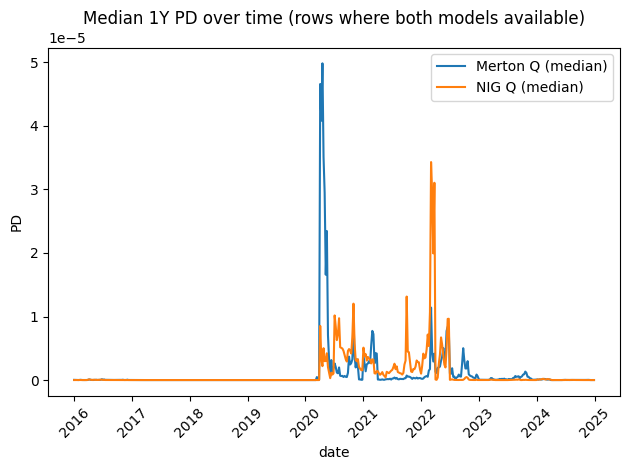

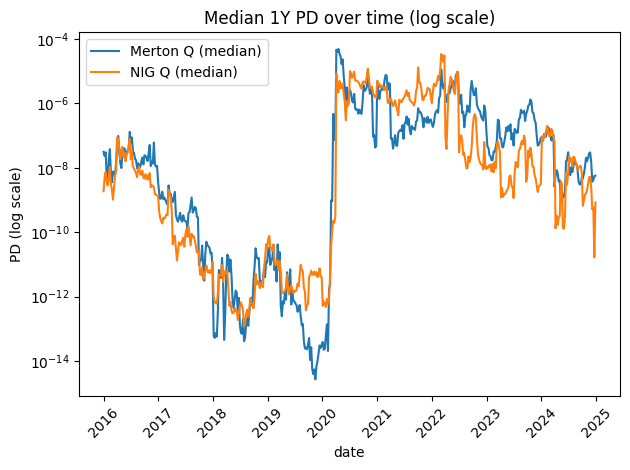

dates: 2016-01-01 00:00:00 → 2024-12-27 00:00:00 | avg firms/date: 19.1


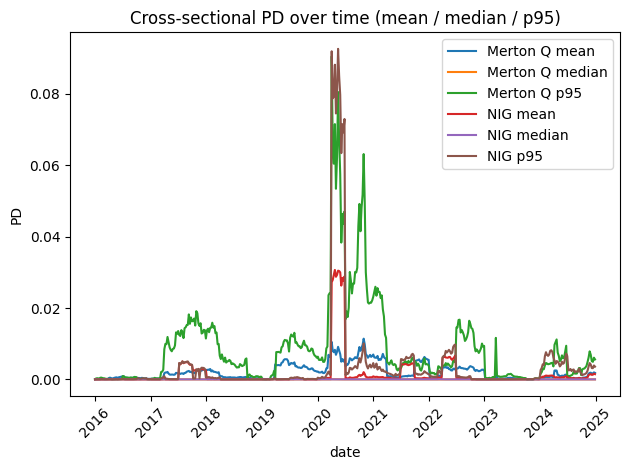

In [2]:
KEYS = ["gvkey", "date"]
BOTH_COLS = ["PD_1y_Merton_Q", "PD_1y_NIG_Q"]


def prepare_panel(df, keep_cols, rename_map, numeric_cols):
    out = (
        df.copy()
          .assign(date=pd.to_datetime(df["date"], errors="coerce"))
          .loc[:, keep_cols]
          .rename(columns=rename_map)
          .sort_values(KEYS)
          .drop_duplicates(KEYS, keep="last")
          .copy()
    )
    out[numeric_cols] = out[numeric_cols].apply(pd.to_numeric, errors="coerce")
    return out


def plot_two_series(ts, col1, col2, label1, label2, title, yscale=None):
    plt.figure()
    plt.plot(ts.index, ts[col1], label=label1)
    plt.plot(ts.index, ts[col2], label=label2)
    if yscale is not None:
        plt.yscale(yscale)
    plt.title(title)
    plt.xlabel("date")
    plt.ylabel("PD" if yscale is None else "PD (log scale)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


def p95(x):
    return np.nanpercentile(x, 95)


# Prepare inputs once
merton_keep = prepare_panel(
    merton,
    keep_cols=["gvkey", "date", "PD_Q", "PD_P"],
    rename_map={"PD_Q": "PD_1y_Merton_Q", "PD_P": "PD_1y_Merton_P"},
    numeric_cols=["PD_1y_Merton_Q", "PD_1y_Merton_P"],
)

nig_keep = prepare_panel(
    nig,
    keep_cols=["gvkey", "date", "PD_Q", "PD_P"],
    rename_map={"PD_Q": "PD_1y_NIG_Q", "PD_P": "PD_1y_NIG_P"},
    numeric_cols=["PD_1y_NIG_Q", "PD_1y_NIG_P"],
)

# Merge once
merged = (
    merton_keep
    .merge(nig_keep, on=KEYS, how="outer", validate="one_to_one")
    .sort_values(KEYS)
    .reset_index(drop=True)
)

print(merged.columns)
print(merged.head())

# Overlap sample: rows where BOTH Merton_Q and NIG_Q are available
mask_both = merged[BOTH_COLS].notna().all(axis=1)

n_both = int(mask_both.sum())
n_total = len(merged)

print("Rows with BOTH (Merton_Q & NIG_Q) non-NaN:", n_both)
print("Share:", n_both / n_total if n_total else np.nan)

df_both = merged.loc[mask_both].copy()

print("kept rows:", len(df_both), "out of", len(merged))
print("kept share:", len(df_both) / len(merged) if len(merged) else np.nan)

# Median time series for the common sample
ts_median = (
    df_both
    .groupby("date")[BOTH_COLS]
    .median()
    .sort_index()
)

plot_two_series(
    ts_median,
    col1="PD_1y_Merton_Q",
    col2="PD_1y_NIG_Q",
    label1="Merton Q (median)",
    label2="NIG Q (median)",
    title="Median 1Y PD over time (rows where both models available)"
)

plot_two_series(
    ts_median,
    col1="PD_1y_Merton_Q",
    col2="PD_1y_NIG_Q",
    label1="Merton Q (median)",
    label2="NIG Q (median)",
    title="Median 1Y PD over time (log scale)",
    yscale="log"
)

# Cross-sectional summary by date on the same common sample
ts_summary = (
    df_both
    .groupby("date")
    .agg(
        merton_mean=("PD_1y_Merton_Q", "mean"),
        merton_med=("PD_1y_Merton_Q", "median"),
        merton_p95=("PD_1y_Merton_Q", p95),
        nig_mean=("PD_1y_NIG_Q", "mean"),
        nig_med=("PD_1y_NIG_Q", "median"),
        nig_p95=("PD_1y_NIG_Q", p95),
        n_firms=("gvkey", "nunique"),
    )
    .sort_index()
)

print(
    "dates:",
    ts_summary.index.min(),
    "→",
    ts_summary.index.max(),
    "| avg firms/date:",
    ts_summary["n_firms"].mean()
)

# Plot summary series
plt.figure()
plt.plot(ts_summary.index, ts_summary["merton_mean"], label="Merton Q mean")
plt.plot(ts_summary.index, ts_summary["merton_med"], label="Merton Q median")
plt.plot(ts_summary.index, ts_summary["merton_p95"], label="Merton Q p95")

plt.plot(ts_summary.index, ts_summary["nig_mean"], label="NIG mean")
plt.plot(ts_summary.index, ts_summary["nig_med"], label="NIG median")
plt.plot(ts_summary.index, ts_summary["nig_p95"], label="NIG p95")

plt.title("Cross-sectional PD over time (mean / median / p95)")
plt.xlabel("date")
plt.ylabel("PD")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### CDS VS PD FIRST OUTLOOK

In [ ]:
# ensure types
merged2 = df_both.copy()
merged2["gvkey"] = merged2["gvkey"].astype(str)
merged2["date"]  = pd.to_datetime(merged2["date"])

cds2 = cds.copy()
cds2["gvkey"] = cds2["gvkey"].astype(str)
cds2["date"]  = pd.to_datetime(cds2["date"])

# keep only firms that exist in BOTH (drop firms with no CDS)
common_gv = sorted(set(merged2["gvkey"].unique()) & set(cds2["gvkey"].unique()))
merged2 = merged2[merged2["gvkey"].isin(common_gv)].copy()
cds2    = cds2[cds2["gvkey"].isin(common_gv)].copy()

# also drop CDS rows whose dates are outside merged's date range
dmin, dmax = merged2["date"].min(), merged2["date"].max()
cds2 = cds2[(cds2["date"] >= dmin) & (cds2["date"] <= dmax)].copy()

# merge-asof onto merged's dates (direction='backward')
merged2 = merged2.sort_values(["date", "gvkey"]).reset_index(drop=True)
cds2    = cds2.sort_values(["date", "gvkey"]).reset_index(drop=True)

merged_cds = pd.merge_asof(
    merged2,
    cds2,
    on="date",
    by="gvkey",
    direction="backward",
    allow_exact_matches=True,
)

# drop rows where CDS still missing (e.g., early dates before first CDS quote)
pd_cds_full = merged_cds.dropna(subset=["cds"]).reset_index(drop=True)

print("firms after intersection:", pd_cds_full["gvkey"].nunique())
print("rows after merge:", len(pd_cds_full))
print("date range:", pd_cds_full["date"].min(), "→", pd_cds_full["date"].max())

firms after intersection: 21
rows after merge: 8976
date range: 2016-01-01 00:00:00 → 2024-12-27 00:00:00


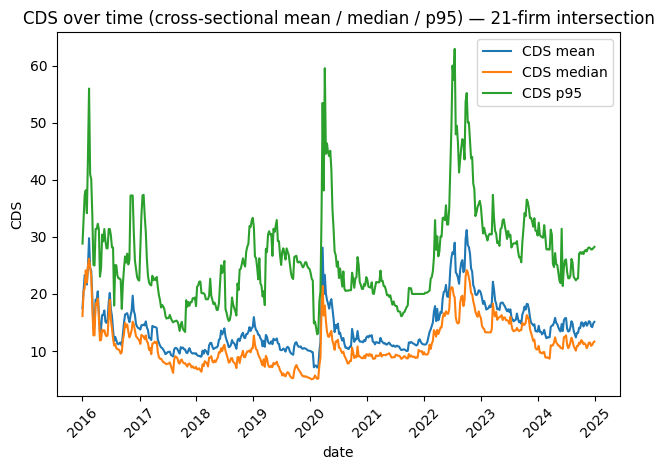

In [4]:
# cds only print
df = pd_cds_full.copy()
df["date"] = pd.to_datetime(df["date"])

ts_cds = (
    df.groupby("date")["cds"]
      .agg(
          mean="mean",
          median="median",
          p95=lambda x: np.nanpercentile(x, 95),
          n_firms=lambda x: x.notna().sum()
      )
      .sort_index()
)

plt.figure()
plt.plot(ts_cds.index, ts_cds["mean"], label="CDS mean")
plt.plot(ts_cds.index, ts_cds["median"], label="CDS median")
plt.plot(ts_cds.index, ts_cds["p95"], label="CDS p95")
plt.title("CDS over time (cross-sectional mean / median / p95) — 21-firm intersection")
plt.xlabel("date")
plt.ylabel("CDS")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

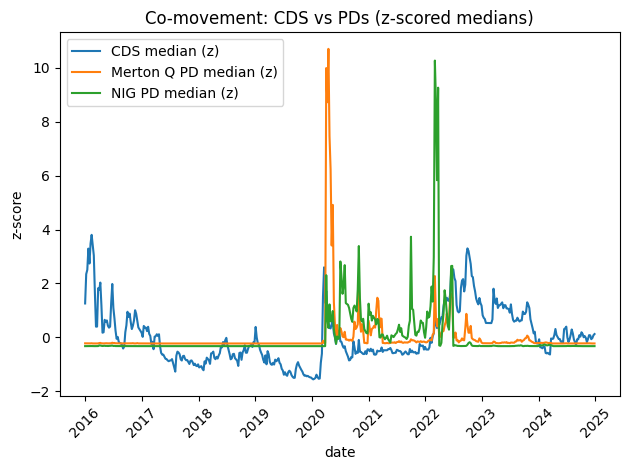

In [5]:
#  CDS and PD using standardized units: z-scoring to visualize co-movement
df0 = pd_cds_full.copy()
df0["date"] = pd.to_datetime(df0["date"])

# time series objects
ts_cds = (
    df0.groupby("date")["cds"]
       .median()
       .sort_index()
       .rename("CDS_median")
)

ts_pd = (
    df0.groupby("date")[["PD_1y_Merton_Q", "PD_1y_NIG_Q"]]
       .median()
       .sort_index()
)

# z-score plot
def zscore(s):
    s = s.astype(float)
    return (s - s.mean()) / s.std(ddof=0)

combo = pd.concat(
    [ts_cds, ts_pd["PD_1y_Merton_Q"].rename("MertonQ_PD_median"), ts_pd["PD_1y_NIG_Q"].rename("NIG_PD_median")],
    axis=1
).dropna()

combo_z = combo.apply(zscore)

plt.figure()
plt.plot(combo_z.index, combo_z["CDS_median"], label="CDS median (z)")
plt.plot(combo_z.index, combo_z["MertonQ_PD_median"], label="Merton Q PD median (z)")
plt.plot(combo_z.index, combo_z["NIG_PD_median"], label="NIG PD median (z)")
plt.title("Co-movement: CDS vs PDs (z-scored medians)")
plt.xlabel("date")
plt.ylabel("z-score")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### CDS IMPLIED PD CALCULATION

In [6]:
# import risk free data as input
rf = pd.read_csv("../data/raw/ecb_yc_1y_aaa.csv", parse_dates=["date"])
rf = rf.rename(columns={"r_1y": "r_f"}).copy()
rf["date"] = pd.to_datetime(rf["date"])
rf["r_f"] = pd.to_numeric(rf["r_f"], errors="coerce")

# convert % -> decimal if needed
if rf["r_f"].median(skipna=True) > 0.5:
    rf["r_f"] = rf["r_f"] / 100.0

rf = rf.dropna(subset=["date", "r_f"]).sort_values("date").reset_index(drop=True)

df = pd_cds_full.copy()
df["date"] = pd.to_datetime(df["date"])

# drop any existing r_f to avoid duplicate columns
df = df.drop(columns=["r_f"], errors="ignore").sort_values("date").reset_index(drop=True)

df = pd.merge_asof(df, rf[["date", "r_f"]], on="date", direction="backward")

print("Missing r_f share:", df["r_f"].isna().mean())
print(df.head())


Missing r_f share: 0.0
    gvkey       date  PD_1y_Merton_Q  PD_1y_Merton_P   PD_1y_NIG_Q  \
0  100022 2016-01-01    6.669224e-05    1.878097e-06  1.390587e-06   
1   61616 2016-01-01    2.818960e-05    4.187336e-05  4.300938e-06   
2  241456 2016-01-01    4.968765e-08    3.761505e-09  6.536715e-09   
3   23671 2016-01-01    1.432740e-07    2.287444e-07  4.946274e-07   
4   23667 2016-01-01    2.873660e-11    1.258532e-12  4.340701e-09   

    PD_1y_NIG_P     cds       r_f  
0  1.800862e-07  28.776 -0.003968  
1  2.218740e-05  23.660 -0.003968  
2  3.184252e-09  20.390 -0.003968  
3  3.570335e-08  27.710 -0.003968  
4  1.254954e-10  12.680 -0.003968  


In [7]:
def _to_spread_decimal(cds, unit="auto"):
    """
    Convert CDS quotes to annual spread in decimal (e.g., 100 bps -> 0.01).
    unit: 'bps' | 'decimal' | 'auto'
    """
    x = pd.to_numeric(cds, errors="coerce").astype(float).to_numpy()
    med = np.nanmedian(x)
    if unit == "auto":
        # heuristic: if median > 1, it's almost surely in bps (e.g. 50..500)
        unit = "bps" if med > 1.0 else "decimal"
    if unit == "bps":
        return x / 1e4
    if unit == "decimal":
        return x
    raise ValueError("unit must be 'bps', 'decimal', or 'auto'")

def cds_pd_triangle(cds, R=0.40, T=1.0, unit="auto"):
    """
    Credit triangle / flat hazard approximation:
        lambda ≈ S/(1-R), PD(0,T) = 1 - exp(-lambda T)
    """
    S = _to_spread_decimal(cds, unit=unit)
    lam = S / max(1e-12, (1.0 - R))
    pd_ = 1.0 - np.exp(-lam * T)
    return pd_, lam

def cds_pd_par_1y_flat_hazard(
    cds,
    r=0.0,
    R=0.40,
    unit="auto",
    pay_freq=4,
    T=1.0,
    max_iter=60,
):
    """
    Single-tenor par-CDS calibration with flat hazard over [0,T], quarterly premium payments,
    and a standard accrual-on-default approximation (half-period accrual).

    We solve for lambda such that:
        S * [sum(delta_i P(t_i) Q(t_i)) + sum(0.5*delta_i P(t_i) (Q(t_{i-1}) - Q(t_i)))]
        = (1-R) * sum(P(t_i) (Q(t_{i-1}) - Q(t_i)))

    This is the standard premium-leg / protection-leg decomposition used in practitioner CDS
    valuation references (RPV01 concept) and is consistent with the ISDA CDS standard model
    “par spread via legs” structure (though ISDA uses full date schedules/calendars). :contentReference[oaicite:1]{index=1}
    """
    S = _to_spread_decimal(cds, unit=unit)
    S = np.asarray(S, dtype=float)
    n = S.shape[0]

    r = np.asarray(pd.to_numeric(r, errors="coerce").fillna(0.0), dtype=float)
    if r.shape == ():
        r = np.full(n, float(r))
    if r.shape[0] != n:
        raise ValueError("r must be scalar or same length as cds")

    # payment grid
    dt = 1.0 / pay_freq
    t = np.arange(dt, T + 1e-12, dt)  # e.g. 0.25,0.5,0.75,1.0
    delta = np.full_like(t, dt)
    m = t.size

    # discount factors (flat curve per row)
    P = np.exp(-r[:, None] * t[None, :])

    def f(lam):
        lam = np.asarray(lam, dtype=float)
        Q = np.exp(-lam[:, None] * t[None, :])
        Qprev = np.concatenate([np.ones((n, 1)), Q[:, :-1]], axis=1)
        dQ = Qprev - Q  # default prob mass per interval

        rpv01 = (delta[None, :] * P * Q).sum(axis=1) + (0.5 * delta[None, :] * P * dQ).sum(axis=1)
        prot = (1.0 - R) * (P * dQ).sum(axis=1)
        return S * rpv01 - prot

    # bisection: f(low) > 0 (no defaults => prem>0, prot~0), f(high) < 0
    low = np.full(n, 1e-12)
    high = np.full(n, 5.0)  # start

    f_low = f(low)
    f_high = f(high)

    # expand high where needed
    need = f_high > 0
    it_expand = 0
    while np.any(need) and it_expand < 20:
        high[need] *= 2.0
        f_high = f(high)
        need = f_high > 0
        it_expand += 1

    # if still not bracketed (very extreme cases), cap and proceed
    high = np.minimum(high, 200.0)
    f_high = f(high)

    # bisection iterations
    for _ in range(max_iter):
        mid = 0.5 * (low + high)
        f_mid = f(mid)
        pos = f_mid > 0
        low[pos] = mid[pos]
        high[~pos] = mid[~pos]

    lam_hat = 0.5 * (low + high)
    pd_1y = 1.0 - np.exp(-lam_hat * T)
    return pd_1y, lam_hat

In [15]:
R = 0.40
df["PD_1y_CDS_triangle"], df["haz_CDS_triangle"] = cds_pd_triangle(df["cds"], R=R, unit="auto")

df["PD_1y_CDS_par"], df["haz_CDS_par"] = cds_pd_par_1y_flat_hazard(
    df["cds"],
    r=df["r_f"],
    R=R,
    unit="auto",
    pay_freq=4,
    T=1.0
)

print("Spearman(cds, PD_triangle):", df["cds"].corr(df["PD_1y_CDS_triangle"], method="spearman"))
print("Spearman(cds, PD_par):     ", df["cds"].corr(df["PD_1y_CDS_par"], method="spearman"))
full = df.copy()

Spearman(cds, PD_triangle): 1.0
Spearman(cds, PD_par):      0.9999999998174732


### EVALUATION PART

,model,benchmark,N,Bias_PD,MAE_PD,RMSE_PD,MAPE_PD_%,Bias_logPD,MAE_logPD,RMSE_logPD
1,PD_1y_NIG_Q,PD_1y_CDS_par,8888,-0.000843,0.003447,0.020446,135.196323,-12.459648,12.536457,14.371619
0,PD_1y_Merton_Q,PD_1y_CDS_par,8888,-0.000388,0.003633,0.010344,147.012419,-12.385781,12.623919,14.617610


,model,benchmark,firm_level_mean_rho_levels,firm_level_mean_rho_changes,firm_level_mean_rhoS_levels,firm_level_mean_MAE_delta_PD_bps,cs_by_date_mean_spearman,cs_by_date_mean_pearson,n_firms_used,n_dates_used
0,PD_1y_Merton_Q,PD_1y_CDS_par,0.080526,0.119307,0.240861,4.550015,0.493900,0.266730,21,470
1,PD_1y_NIG_Q,PD_1y_CDS_par,0.121603,0.112118,0.178581,4.928571,0.434921,0.282878,21,470


DM/HAC test: {'T': 470, 'mean': 7.116268716880635, 'se_hac': 3.7405690630116033, 'z': 1.9024561763207204, 'p': 0.05711154287506082, 'L': 5, 'modelA': 'PD_1y_Merton_Q', 'modelB': 'PD_1y_NIG_Q', 'benchmark': 'PD_1y_CDS_par', 'loss': 'sq_log'}


,metric,N_firms,t,p,mean_diff
0,rho_levels,21,-1.041458,0.297663,-0.041077
1,rho_changes,21,0.296939,0.766513,0.007189


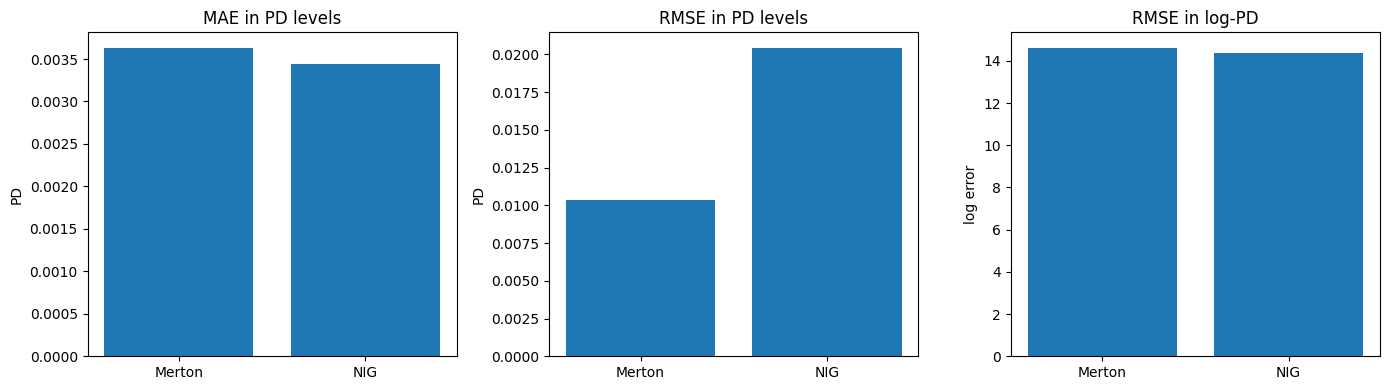

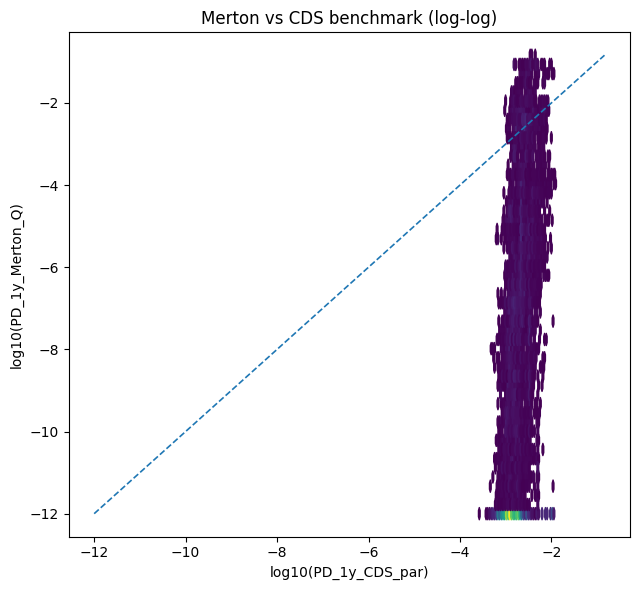

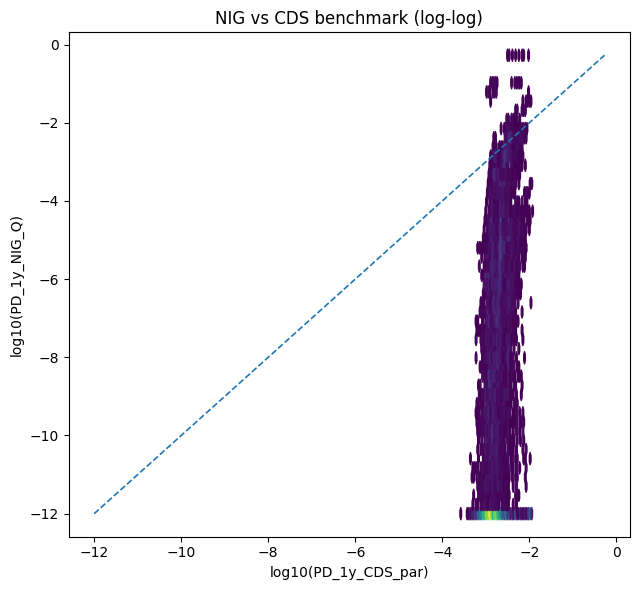

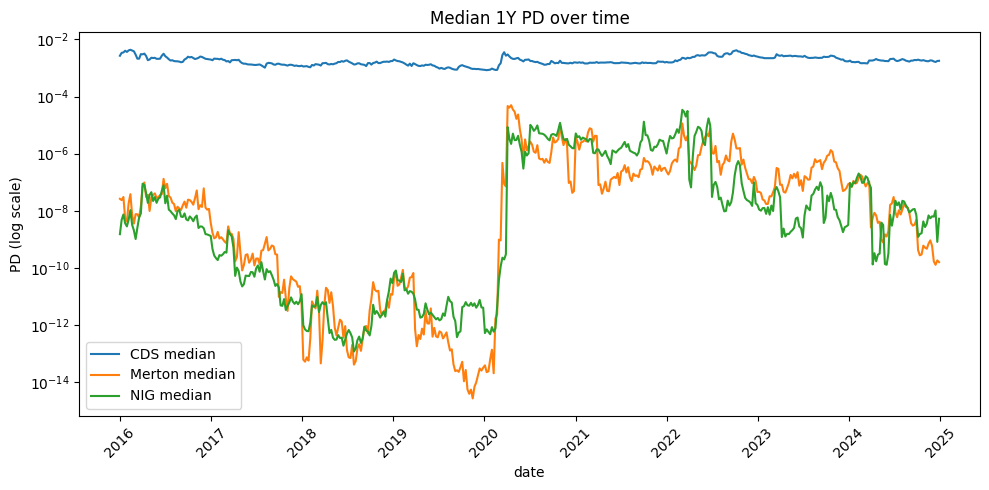

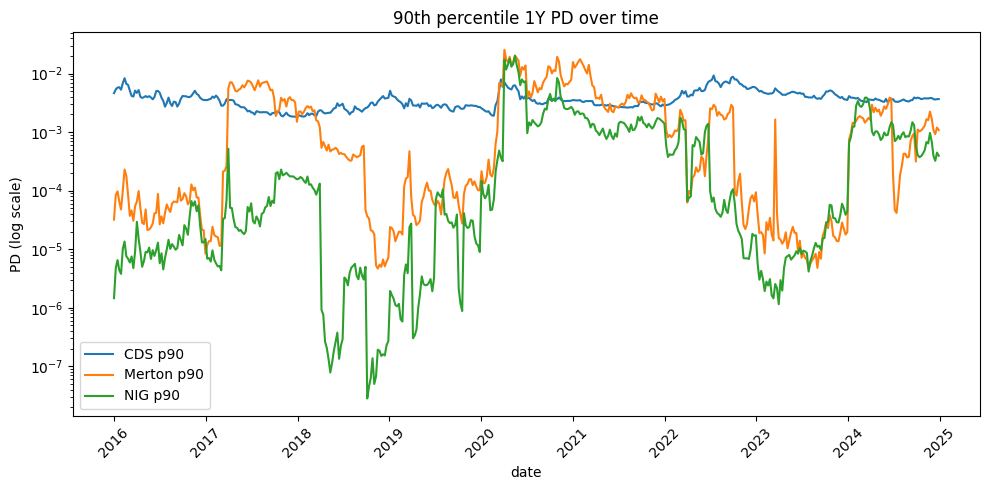

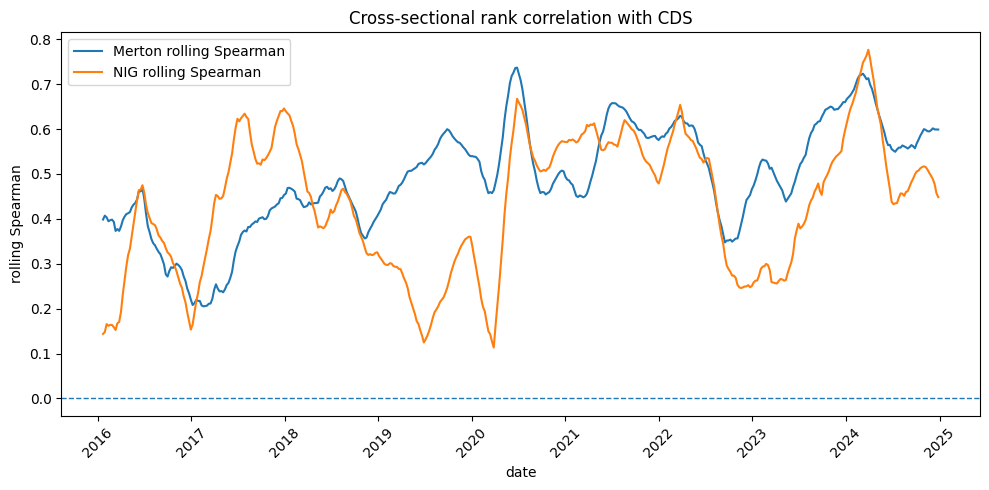

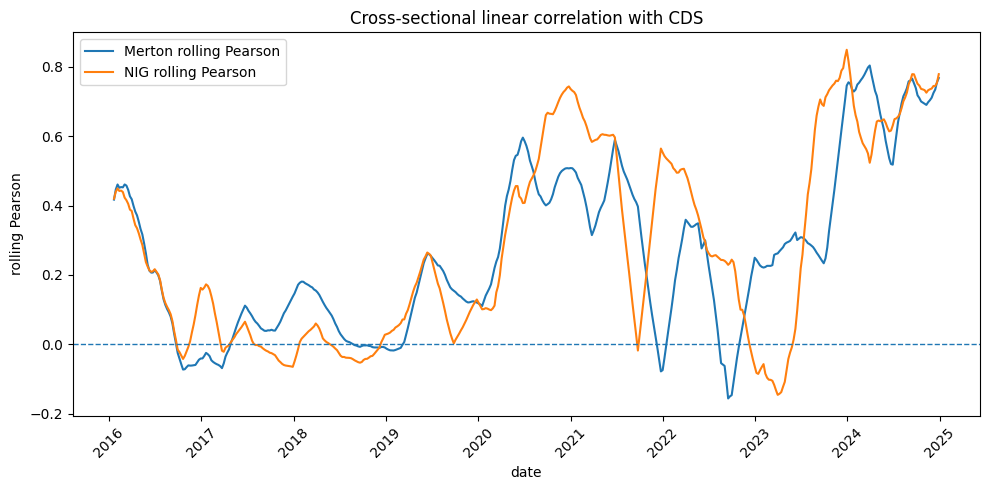

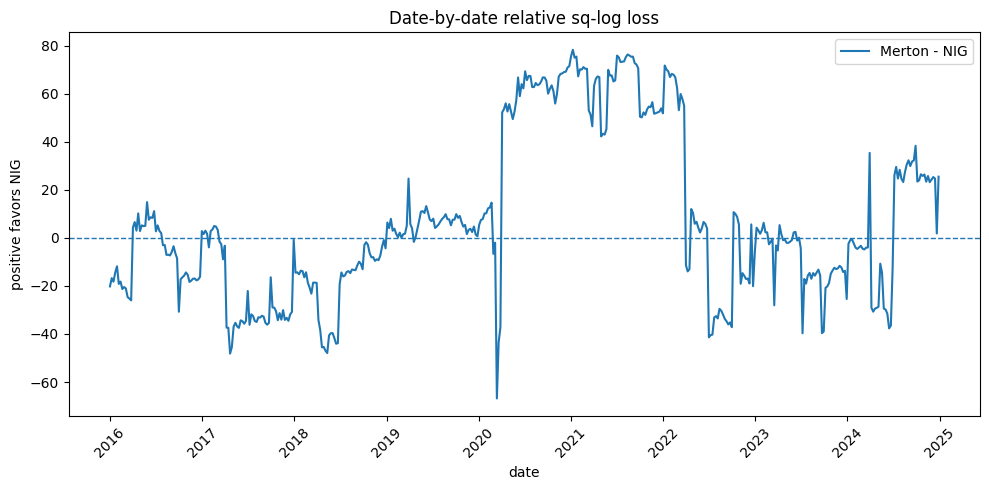

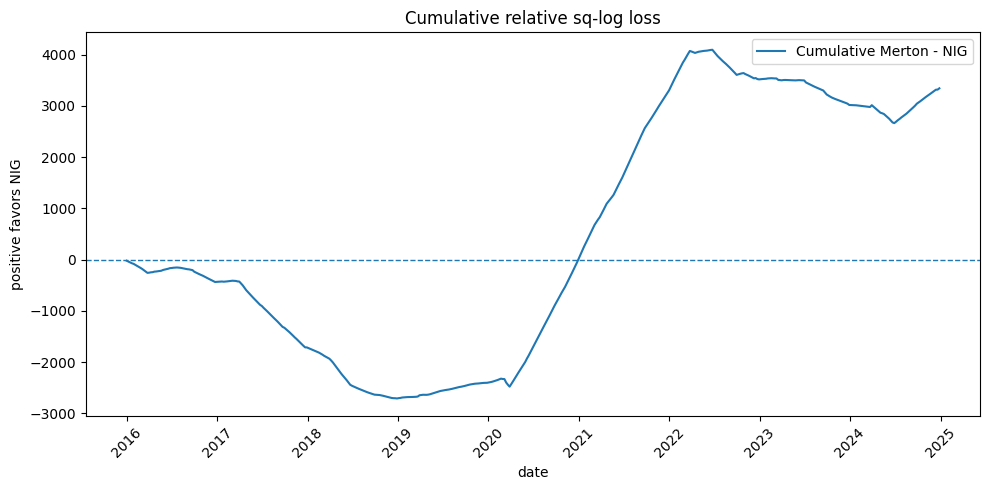

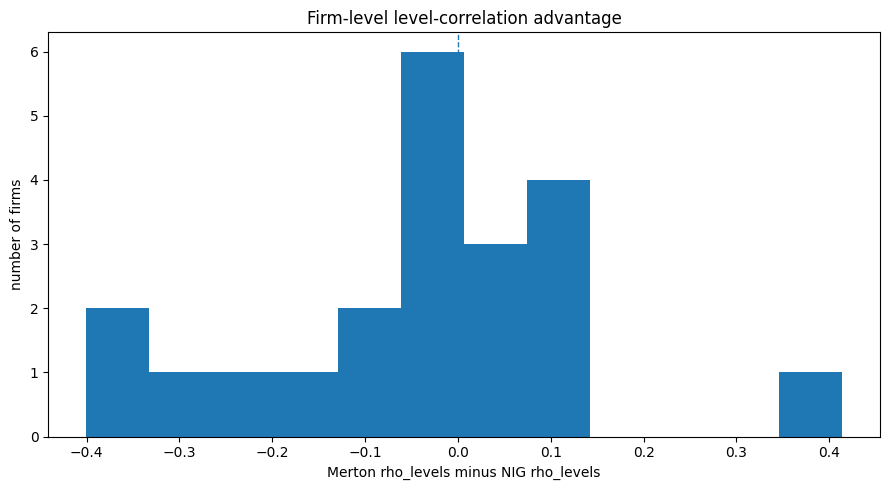

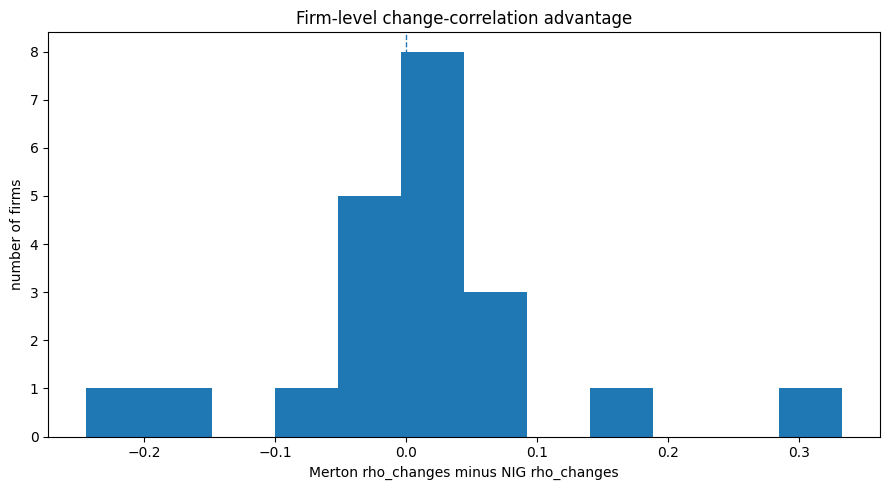

,gvkey,delta_rho_levels_M_minus_N,merton_rho_levels,nig_rho_levels
0,100022,0.413899,0.489722,0.075822
6,101361,0.127302,0.020031,-0.107271
11,19349,0.100915,0.632597,0.531682
14,221244,0.097327,-0.245591,-0.342918
10,17452,0.074701,-0.121763,-0.196465
13,220940,0.068824,0.043615,-0.025209
7,102296,0.031952,-0.087706,-0.119658
16,222379,0.012533,0.193996,0.181463
12,201794,-0.015892,0.220635,0.236527
15,221616,-0.020261,-0.050830,-0.030568


,gvkey,delta_rho_levels_M_minus_N,merton_rho_levels,nig_rho_levels
1,100080,-0.400656,-0.002273,0.398383
5,101336,-0.365935,-0.141037,0.224898
18,23671,-0.277515,-0.260065,0.017451
19,241456,-0.234717,0.158819,0.393536
8,14447,-0.132942,0.103752,0.236694
9,17436,-0.112801,0.286793,0.399595
20,61616,-0.084341,0.259103,0.343444
4,101204,-0.043826,0.048683,0.092509
17,23667,-0.040757,-0.034448,0.006309
3,101202,-0.031198,-0.059048,-0.027850


In [20]:
eval_df = full.copy()

eval_df["date"] = pd.to_datetime(eval_df["date"], errors="coerce")
eval_df["gvkey"] = eval_df["gvkey"].astype(str)

bench = "PD_1y_CDS_par"  # choice stated in report
models = [c for c in ["PD_1y_Merton_Q", "PD_1y_NIG_Q"] if c in eval_df.columns]

merton_col = "PD_1y_Merton_Q"
nig_col    = "PD_1y_NIG_Q"

eps = 1e-12
min_firms_date = 10
roll_weeks = 13
min_obs_firm = 30
for c in [bench] + models:
    eval_df[c] = pd.to_numeric(eval_df[c], errors="coerce")

plot_df = (
    eval_df.dropna(subset=["gvkey", "date", bench] + models)
           .loc[lambda x: (x[bench] > 0) & (x[merton_col] > 0) & (x[nig_col] > 0)]
           .copy()
)


# 1) Recompute results once on the same plotting panel

results = evaluate_models_vs_cds(
    df=plot_df,
    models=models,
    bench_col=bench,
    id_col="gvkey",
    date_col="date",
    eps_log=eps,
    mape_floor=1e-6,
    min_obs_firm=min_obs_firm,
    min_firms_date=min_firms_date,
    loss_for_dm="sq_log",
)

display(results["level_fit"].sort_values("RMSE_logPD"))
display(results["tracking"])
print("DM/HAC test:", results["dm_test"])
display(results["paired_corr_tests"])


# 2) Date-level tracking outputs from the attached module

trk_m = tracking_metrics(
    plot_df, merton_col, bench,
    id_col="gvkey", date_col="date",
    min_obs_firm=min_obs_firm, min_firms_date=min_firms_date,
    use_log_changes=False, eps_log=eps
)

trk_n = tracking_metrics(
    plot_df, nig_col, bench,
    id_col="gvkey", date_col="date",
    min_obs_firm=min_obs_firm, min_firms_date=min_firms_date,
    use_log_changes=False, eps_log=eps
)

m_date = trk_m["date_metrics_df"].set_index("date").sort_index()
n_date = trk_n["date_metrics_df"].set_index("date").sort_index()

firm_m = results["firm_metrics"][merton_col].copy()
firm_n = results["firm_metrics"][nig_col].copy()


# 3) Plot A: level-fit table as a compact bar chart

lvl = results["level_fit"].set_index("model").loc[[merton_col, nig_col]]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(["Merton", "NIG"], lvl["MAE_PD"])
axes[0].set_title("MAE in PD levels")
axes[0].set_ylabel("PD")

axes[1].bar(["Merton", "NIG"], lvl["RMSE_PD"])
axes[1].set_title("RMSE in PD levels")
axes[1].set_ylabel("PD")

axes[2].bar(["Merton", "NIG"], lvl["RMSE_logPD"])
axes[2].set_title("RMSE in log-PD")
axes[2].set_ylabel("log error")

plt.tight_layout()
plt.show()


# 4) Plot B: log-log scatter against CDS benchmark

for m, label in [(merton_col, "Merton"), (nig_col, "NIG")]:
    x = np.log10(np.clip(plot_df[bench].values, eps, None))
    y = np.log10(np.clip(plot_df[m].values, eps, None))

    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())

    plt.figure(figsize=(6.5, 6))
    plt.hexbin(x, y, gridsize=45, mincnt=1)
    plt.plot([lo, hi], [lo, hi], "--", linewidth=1.2)
    plt.xlabel(f"log10({bench})")
    plt.ylabel(f"log10({m})")
    plt.title(f"{label} vs CDS benchmark (log-log)")
    plt.tight_layout()
    plt.show()


# 5) Plot C: median and p90 through time

ts = (
    plot_df.groupby("date")
    .agg(
        cds_med=(bench, "median"),
        merton_med=(merton_col, "median"),
        nig_med=(nig_col, "median"),
        cds_p90=(bench, lambda s: s.quantile(0.90)),
        merton_p90=(merton_col, lambda s: s.quantile(0.90)),
        nig_p90=(nig_col, lambda s: s.quantile(0.90)),
        n_firms=("gvkey", "nunique"),
    )
    .query("n_firms >= @min_firms_date")
    .sort_index()
)

plt.figure(figsize=(10, 5))
plt.plot(ts.index, ts["cds_med"], label="CDS median")
plt.plot(ts.index, ts["merton_med"], label="Merton median")
plt.plot(ts.index, ts["nig_med"], label="NIG median")
plt.yscale("log")
plt.title("Median 1Y PD over time")
plt.xlabel("date")
plt.ylabel("PD (log scale)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(ts.index, ts["cds_p90"], label="CDS p90")
plt.plot(ts.index, ts["merton_p90"], label="Merton p90")
plt.plot(ts.index, ts["nig_p90"], label="NIG p90")
plt.yscale("log")
plt.title("90th percentile 1Y PD over time")
plt.xlabel("date")
plt.ylabel("PD (log scale)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# 6) Plot D: rolling cross-sectional correlations by date

plt.figure(figsize=(10, 5))
plt.plot(
    m_date.index,
    m_date["cs_spearman"].rolling(roll_weeks, min_periods=4).mean(),
    label="Merton rolling Spearman"
)
plt.plot(
    n_date.index,
    n_date["cs_spearman"].rolling(roll_weeks, min_periods=4).mean(),
    label="NIG rolling Spearman"
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Cross-sectional rank correlation with CDS")
plt.xlabel("date")
plt.ylabel("rolling Spearman")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(
    m_date.index,
    m_date["cs_pearson"].rolling(roll_weeks, min_periods=4).mean(),
    label="Merton rolling Pearson"
)
plt.plot(
    n_date.index,
    n_date["cs_pearson"].rolling(roll_weeks, min_periods=4).mean(),
    label="NIG rolling Pearson"
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Cross-sectional linear correlation with CDS")
plt.xlabel("date")
plt.ylabel("rolling Pearson")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# 7) Plot E: date-by-date sq-log loss differential
#     positive = NIG better

tmp = plot_df[["date", bench, merton_col, nig_col]].copy()
tmp["merton_sqlog"] = (np.log(tmp[merton_col] + eps) - np.log(tmp[bench] + eps)) ** 2
tmp["nig_sqlog"] = (np.log(tmp[nig_col] + eps) - np.log(tmp[bench] + eps)) ** 2

loss_by_date = (
    tmp.groupby("date")
       .agg(
           merton_sqlog=("merton_sqlog", "mean"),
           nig_sqlog=("nig_sqlog", "mean"),
           n_obs=(bench, "size"),
       )
       .sort_index()
)

loss_by_date["diff_M_minus_N"] = loss_by_date["merton_sqlog"] - loss_by_date["nig_sqlog"]
loss_by_date["cum_diff_M_minus_N"] = loss_by_date["diff_M_minus_N"].cumsum()

plt.figure(figsize=(10, 5))
plt.plot(loss_by_date.index, loss_by_date["diff_M_minus_N"], label="Merton - NIG")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Date-by-date relative sq-log loss")
plt.xlabel("date")
plt.ylabel("positive favors NIG")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(loss_by_date.index, loss_by_date["cum_diff_M_minus_N"], label="Cumulative Merton - NIG")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Cumulative relative sq-log loss")
plt.xlabel("date")
plt.ylabel("positive favors NIG")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# 8) Plot F: firm-level heterogeneity from results["firm_metrics"]

firm_cmp = (
    firm_m[["gvkey", "rho_levels", "rho_changes", "rhoS_levels", "MAE_delta", "n_obs"]]
    .rename(columns={
        "rho_levels": "merton_rho_levels",
        "rho_changes": "merton_rho_changes",
        "rhoS_levels": "merton_rhoS_levels",
        "MAE_delta": "merton_MAE_delta",
        "n_obs": "merton_n_obs",
    })
    .merge(
        firm_n[["gvkey", "rho_levels", "rho_changes", "rhoS_levels", "MAE_delta", "n_obs"]]
        .rename(columns={
            "rho_levels": "nig_rho_levels",
            "rho_changes": "nig_rho_changes",
            "rhoS_levels": "nig_rhoS_levels",
            "MAE_delta": "nig_MAE_delta",
            "n_obs": "nig_n_obs",
        }),
        on="gvkey",
        how="inner",
    )
)

firm_cmp["delta_rho_levels_M_minus_N"] = firm_cmp["merton_rho_levels"] - firm_cmp["nig_rho_levels"]
firm_cmp["delta_rho_changes_M_minus_N"] = firm_cmp["merton_rho_changes"] - firm_cmp["nig_rho_changes"]

plt.figure(figsize=(9, 5))
plt.hist(firm_cmp["delta_rho_levels_M_minus_N"].dropna(), bins=12)
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Firm-level level-correlation advantage")
plt.xlabel("Merton rho_levels minus NIG rho_levels")
plt.ylabel("number of firms")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.hist(firm_cmp["delta_rho_changes_M_minus_N"].dropna(), bins=12)
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Firm-level change-correlation advantage")
plt.xlabel("Merton rho_changes minus NIG rho_changes")
plt.ylabel("number of firms")
plt.tight_layout()
plt.show()

display(
    firm_cmp.sort_values("delta_rho_levels_M_minus_N", ascending=False)
            [["gvkey", "delta_rho_levels_M_minus_N", "merton_rho_levels", "nig_rho_levels"]]
            .head(10)
)

display(
    firm_cmp.sort_values("delta_rho_levels_M_minus_N", ascending=True)
            [["gvkey", "delta_rho_levels_M_minus_N", "merton_rho_levels", "nig_rho_levels"]]
            .head(10)
)